# EDA Pipeline (revised)

- Zero-imputation: district-years with zero events included 
- NDBI source: `indonesia_ndbi_ndvi_2019.csv` — Landsat 8, dry-season Apr–Oct 2019, CLOUD<20%, GAUL Level 2, scale=150m
- Panel: 448 districts × 6 years = 2,688 district-years (balanced per district)
- Analytical cross-section: 395 districts (NDBI - GADM - ACLED crosswalk)


### Setup

In [2]:
import os
os.chdir("/Users/annisa/Library/CloudStorage/OneDrive-TheUniversityofChicago/Coursework/2026_Spring/30200-css-research-design/spatial-contention")
print(os.getcwd())


/Users/annisa/Library/CloudStorage/OneDrive-TheUniversityofChicago/Coursework/2026_Spring/30200-css-research-design/spatial-contention


In [4]:
import subprocess, sys
for pkg in ["libpysal", "esda", "spreg", "rapidfuzz", "geopandas", "scikit-learn"]:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg,
                    "--break-system-packages", "-q"], check=False)


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import numpy as np
import libpysal
from esda.moran import Moran, Moran_Local
from scipy.stats import spearmanr
from scipy.stats import norm, t as tdist
from sklearn.linear_model import LinearRegression
from spreg import OLS, ML_Lag, ML_Error
from pathlib import Path

DATA = Path("data")
PROC = Path("data/processed")
FIGS = Path("figures")
for p in [PROC, FIGS]: p.mkdir(parents=True, exist_ok=True)

REGION_COLORS = {
    "Sumatra":"#E76F51",
    "Java":"#2A9D8F",
    "Bali & NT":      "#E9C46A",
    "Kalimantan":     "#264653",
    "Sulawesi":       "#F4A261",
    "Maluku" : "#457B9D",
    "Papua" : "#1D3557",
}
plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "sans-serif",
    "font.size":         10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.labelsize":    10,
    "axes.titlesize":    10,
    "legend.fontsize":   8,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
})


### 1. Load data

In [41]:
acled_cl = pd.read_csv(DATA / "acled_classified_crosswalked.csv",
                       parse_dates=["event_date"])
ndbi_raw = pd.read_csv(DATA / "indonesia_ndbi_ndvi_2019.csv")
cs_prev  = pd.read_csv(DATA / "district_ndbi_repression_panel.csv")

print(f"ACLED: {len(acled_cl):,} events | {acled_cl.event_date.min().date()} → {acled_cl.event_date.max().date()}")
print(f"Categories: {acled_cl.category.value_counts().to_dict()}")
print(f"NDBI: {len(ndbi_raw)} districts")
print(f"Cross-section (prev): {len(cs_prev)} districts")


ACLED: 15,564 events | 2019-01-07 → 2025-01-31
Categories: {'protest': 14367, 'excluded': 650, 'routine': 534, 'lethal': 13}
NDBI: 443 districts
Cross-section (prev): 395 districts


In [ ]:
gadm = gpd.read_file(DATA / "gadm41_IDN_2.json")
print(f"GADM loaded: {len(gadm)} districts")

GADM loaded: 502 districts


### 2. NDBI data characteristics

| Property | Value | Implication |
|---|---|---|
| Boundary set | FAO GAUL Level 2 (2015) | 443 districts — post-2014 partition missing |
| Temporal window | 2019-04-01 → 2019-10-31 | Dry-season median composite — fixed moderator |
| Cloud filter | CLOUD_COVER < 20% (scene-level) | Per-pixel CFMask not applied |
| Resolution | scale=150m | Resampled from 30m native |
| Composite | landsat.median() | Robust to residual cloud artifacts |
| Valid districts | 436/443 | 7 NaN from cloud saturation |


## 3. Build zero-imputed panel (2019–2024)

In [44]:
# 1. Unique districts from ACLED crosswalk
years = [y for y in sorted(acled_cl.year.unique()) if y != 2025]
all_districts = (acled_cl[acled_cl.GID_2.notna()]
                 [["GID_2","admin2","NAME_1","region"]]
                 .drop_duplicates("GID_2"))
print(f"Unique districts in ACLED: {len(all_districts)}")
print(f"Years: {years}")


Unique districts in ACLED: 448
Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [45]:
# 2. Cartesian product district × year
full_index = pd.MultiIndex.from_product(
    [all_districts.GID_2, years], names=["GID_2","year"])
full_panel = (pd.DataFrame(index=full_index).reset_index()
              .merge(all_districts, on="GID_2", how="left"))
print(f"Full panel rows: {len(full_panel)} ({len(all_districts)} districts × {len(years)} years)")


Full panel rows: 2688 (448 districts × 6 years)


In [ ]:
# 3. Aggregate ACLED to district-year
agg = (acled_cl[acled_cl.GID_2.notna() & acled_cl.year.isin(years)]
       .groupby(["GID_2","year","category"]).size()
       .unstack(fill_value=0).reset_index())
for col in ["protest","routine","lethal"]:
    if col not in agg.columns: agg[col] = 0
print(f"Aggregated: {len(agg)} district-years with ≥1 event")


Aggregated: 1849 district-years with ≥1 event


In [47]:
# 4. Merge onto full panel — zero-impute missing cells
panel = (full_panel
         .merge(agg[["GID_2","year","protest","routine","lethal"]],
                on=["GID_2","year"], how="left")
         .fillna({"protest":0,"routine":0,"lethal":0}))
panel[["protest","routine","lethal"]] = panel[["protest","routine","lethal"]].astype(int)
panel["log_protest"] = np.log10(panel.protest + 1)
panel["log_routine"] = np.log10(panel.routine + 1)

print(f"Panel shape: {panel.shape}")
print(f"Zero-protest rows: {(panel.protest==0).sum()} ({(panel.protest==0).mean()*100:.1f}%)")
print(f"Zero-routine rows: {(panel.routine==0).sum()} ({(panel.routine==0).mean()*100:.1f}%)")
print(f"Zero-lethal rows:  {(panel.lethal==0).sum()}  ({(panel.lethal==0).mean()*100:.1f}%)")
print()
print(panel.groupby("year")[["protest","routine","lethal"]].sum().to_string())


Panel shape: (2688, 10)
Zero-protest rows: 910 (33.9%)
Zero-routine rows: 2400 (89.3%)
Zero-lethal rows:  2677  (99.6%)

      protest  routine  lethal
year                          
2019     1216       71       2
2020     1522      118       6
2021     1680      122       1
2022     3051       87       2
2023     3065       57       1
2024     3342       72       1


### 4. Build NDBI cross-section

In [97]:
# Aggregate panel to cross-section, join NDBI from cs_prev crosswalk
panel_agg = (panel.groupby("GID_2")
             .agg(n_protest=("protest","sum"),
                  n_routine=("routine","sum"),
                  n_lethal=("lethal","sum"))
             .reset_index())

cs = (panel_agg
      .merge(cs_prev[["GID_2","NAME_2","NAME_1","region",
                       "GAUL_ADM2_NAME","GAUL_ADM1_NAME",
                       "NDBI_mean","NDVI_mean","NDBI_stdDev","NDVI_stdDev",
                       "urban_gradient_mean"]],
             on="GID_2", how="right")  # ganti inner → right
      .reset_index(drop=True))

cs["n_protest"] = cs.n_protest.fillna(0).astype(int)
cs["n_routine"] = cs.n_routine.fillna(0).astype(int)
cs["n_lethal"]  = cs.n_lethal.fillna(0).astype(int)

cs["log_n_protest"] = np.log10(cs.n_protest + 1)
cs["log_n_routine"] = np.log10(cs.n_routine + 1)
cs["NDBI_c"] = cs.NDBI_mean - cs.NDBI_mean.mean()
cs["NDVI_c"] = cs.NDVI_mean - cs.NDVI_mean.mean()
cs["routine_x_NDBI"] = cs.log_n_routine * cs.NDBI_c

cs.to_csv(PROC / "district_cross_section_v2.csv", index=False)
print(f"Cross-section: {len(cs)} districts")
print(f"NDBI range: {cs.NDBI_mean.min():.4f} to {cs.NDBI_mean.max():.4f}")
print(f"Regions: {cs.region.value_counts().to_dict()}")


Cross-section: 395 districts
NDBI range: -0.5096 to 0.0514
Regions: {'Sumatra': 123, 'Java': 96, 'Sulawesi': 58, 'Kalimantan': 47, 'Maluku & Papua': 39, 'Bali & NT': 32}


In [99]:
# Reassign region
region_remap = {
    "Maluku":      "Maluku",
    "MalukuUtara": "Maluku",
    "Papua":       "Papua",
    "PapuaBarat":  "Papua",
}
cs["region"] = cs.apply(
    lambda row: region_remap.get(row["NAME_1"], row["region"]),
    axis=1
)
if "NAME_1" in panel.columns:
    panel["region"] = panel.apply(
        lambda row: region_remap.get(row["NAME_1"], row["region"]), axis=1)

print(cs.region.value_counts().to_string())

region
Sumatra       123
Java           96
Sulawesi       58
Kalimantan     47
Bali & NT      32
Papua          25
Maluku         14


### 5. Descriptive statistics

In [100]:
vars_desc = {
    "n_protest":  "Protest events (total 2019–2024)",
    "n_routine":  "Routine repression events",
    "n_lethal":   "Lethal repression events",
    "NDBI_mean":  "NDBI (built-up index, dry-season 2019)",
    "NDVI_mean":  "NDVI (vegetation index, dry-season 2019)",
}
rows = []
for col, label in vars_desc.items():
    s = cs[col]
    rows.append({"Variable": label, "N": s.notna().sum(),
                 "Mean": f"{s.mean():.3f}", "SD": f"{s.std():.3f}",
                 "Min": f"{s.min():.3f}", "Median": f"{s.median():.3f}",
                 "Max": f"{s.max():.3f}", "% Zero": f"{(s==0).mean()*100:.1f}%"})
print("Table 0. Summary statistics — district cross-section (n=395)")
print(pd.DataFrame(rows).to_string(index=False))



Table 0. Summary statistics — district cross-section (n=395)
                                Variable   N   Mean     SD    Min Median      Max % Zero
        Protest events (total 2019–2024) 395 32.329 77.448  0.000 11.000 1123.000   5.3%
               Routine repression events 395  1.241  4.309  0.000  0.000   50.000  69.6%
                Lethal repression events 395  0.030  0.199  0.000  0.000    2.000  97.5%
  NDBI (built-up index, dry-season 2019) 395 -0.250  0.105 -0.510 -0.276    0.051   0.0%
NDVI (vegetation index, dry-season 2019) 395  0.626  0.128  0.150  0.655    0.866   0.0%


### 6. Reporting bias diagnostic

In [101]:
import os
print([f for f in os.listdir(DATA) if "acled" in f.lower()])

['acled_classified_crosswalked.csv', 'acled_idn_2019_2025.csv']


In [102]:
print(acled_cl.columns.tolist())

['event_id_cnty', 'event_date', 'year', 'event_type', 'sub_event_type', 'category', 'admin1', 'admin2', 'NAME_1', 'GID_2', 'region', 'location', 'latitude', 'longitude', 'geo_precision', 'fatalities', 'notes', 'source', 'source_scale']


In [104]:
# Merge source_scale from raw ACLED
acled_raw = pd.read_csv(DATA / "acled_idn_2019_2025.csv")
acled_cl  = acled_cl.merge(
    acled_raw[["event_id_cnty","source","source_scale"]],
    on="event_id_cnty", how="left")

print(f"Overall % National source: {(acled_cl.source_scale=='National').mean()*100:.1f}%")
print()
print(acled_cl.source_scale.value_counts().head(8).to_string())




Overall % National source: 94.3%

source_scale
National                  14675
Subnational                 338
Other                       175
New media                    89
Local partner-Regional       57
Subnational-National         50
Other-National               48
International                47


In [105]:
# Zero-rate vs source density per region
zero_rate = (panel.groupby("region", group_keys=False)
             .apply(lambda x: (x.protest==0).mean(), include_groups=False)
             .rename("zero_rate"))

source_density = (acled_cl[acled_cl.GID_2.notna()]
                  .groupby("region")
                  .agg(n_sources=("source","nunique"),
                       pct_national=("source_scale",
                                     lambda x: (x=="National").mean()))
                  .reset_index())

bias_check = zero_rate.reset_index().merge(source_density, on="region")
print("Reporting bias diagnostic:")
print(bias_check.to_string(index=False))
print()
print("Interpretation:")
print("  Java: low zero_rate + high n_sources → reliable coverage")
print("  Papua: moderate zero_rate but coverage concentrated in Jubi + HumanRightsPapua")
print("         --> zeros conflate genuine absence with reporting gaps")


Reporting bias diagnostic:
    region  zero_rate  n_sources  pct_national
 Bali & NT   0.436937         42      0.966460
      Java   0.146465        157      0.979717
Kalimantan   0.445578         28      0.982222
  Sulawesi   0.371429         84      0.973333
   Sumatra   0.403382         78      0.982548

Interpretation:
  Java: low zero_rate + high n_sources → reliable coverage
  Papua: moderate zero_rate but coverage concentrated in Jubi + HumanRightsPapua
         --> zeros conflate genuine absence with reporting gaps


### 7. Spearman rank correlations

In [155]:
# Pooled
rho_pool, p_pool = spearmanr(cs.NDBI_mean, cs.log_n_routine)
print(f"Pooled Spearman (NDBI x log_routine): rho = {rho_pool:.3f}  (p = {p_pool:.2e}, n = {len(cs)})")
print()

# Within-region
print(f"{'Region':<20} {'n':>4} {'rho':>7} {'p':>8}")

for region, grp in cs.groupby("region"):
    if len(grp) < 10: continue
    r, p = spearmanr(grp.NDBI_mean, grp.log_n_routine)
    sig = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.10 else ""
    print(f"{region:<20} {len(grp):>4} {r:>7.3f} {p:>8.4f} {sig}")


Pooled Spearman (NDBI x log_routine): rho = 0.285  (p = 8.23e-09, n = 395)

Region                  n     rho        p
Bali & NT              32   0.320   0.0746 *
Java                   96   0.249   0.0145 **
Kalimantan             47   0.274   0.0625 *
Maluku                 14   0.645   0.0127 **
Papua                  25  -0.227   0.2759 
Sulawesi               58   0.373   0.0039 ***
Sumatra               123   0.178   0.0487 **


#### 7a. Sensitivity check — with vs without 2025

In [157]:
panel_no2025 = panel[panel.year != 2025]
cs_no2025 = (panel_no2025.groupby("GID_2")
             .agg(n_protest=("protest","sum"), n_routine=("routine","sum"))
             .reset_index()
             .merge(cs[["GID_2","NDBI_mean","region"]], on="GID_2", how="inner"))

r_full,   p_full   = spearmanr(cs.NDBI_mean, cs.log_n_routine)
r_no2025, p_no2025 = spearmanr(cs_no2025.NDBI_mean,
                                np.log10(cs_no2025.n_routine+1))
print(f"With 2025:    rho = {r_full:.3f}  (p = {p_full:.4f})")
print(f"Without 2025: rho = {r_no2025:.3f}  (p = {p_no2025:.4f})")
print(f"Delta_rho = {abs(r_full-r_no2025):.4f} -> 2025 does not drive results")


With 2025:    rho = 0.285  (p = 0.0000)
Without 2025: rho = 0.273  (p = 0.0000)
Delta_rho = 0.0117 -> 2025 does not drive results


### 8. Figures

#### Figure 1. Spatial structure of mobilization

In [108]:
protest_total = (acled_cl[acled_cl.category=="protest"]
                 .groupby("GID_2").size().reset_index(name="n_protest"))
gdf_p = (gadm[["GID_2","geometry"]]
         .merge(protest_total, on="GID_2", how="left"))
gdf_p["log_protest"] = np.log10(gdf_p.n_protest.fillna(0) + 1)

/var/folders/1b/zjf94sj90zd_m94w6wlhk5_r0000gn/T/ipykernel_19007/3302646134.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geom = gadm[gadm.GID_2==row.GID_2].geometry.centroid.values[0]
/var/folders/1b/zjf94sj90zd_m94w6wlhk5_r0000gn/T/ipykernel_19007/3302646134.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geom = gadm[gadm.GID_2==row.GID_2].geometry.centroid.values[0]
/var/folders/1b/zjf94sj90zd_m94w6wlhk5_r0000gn/T/ipykernel_19007/3302646134.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geom = gadm[gadm.GID_2==row.GID_2].geometry.centroid.values[0]
/

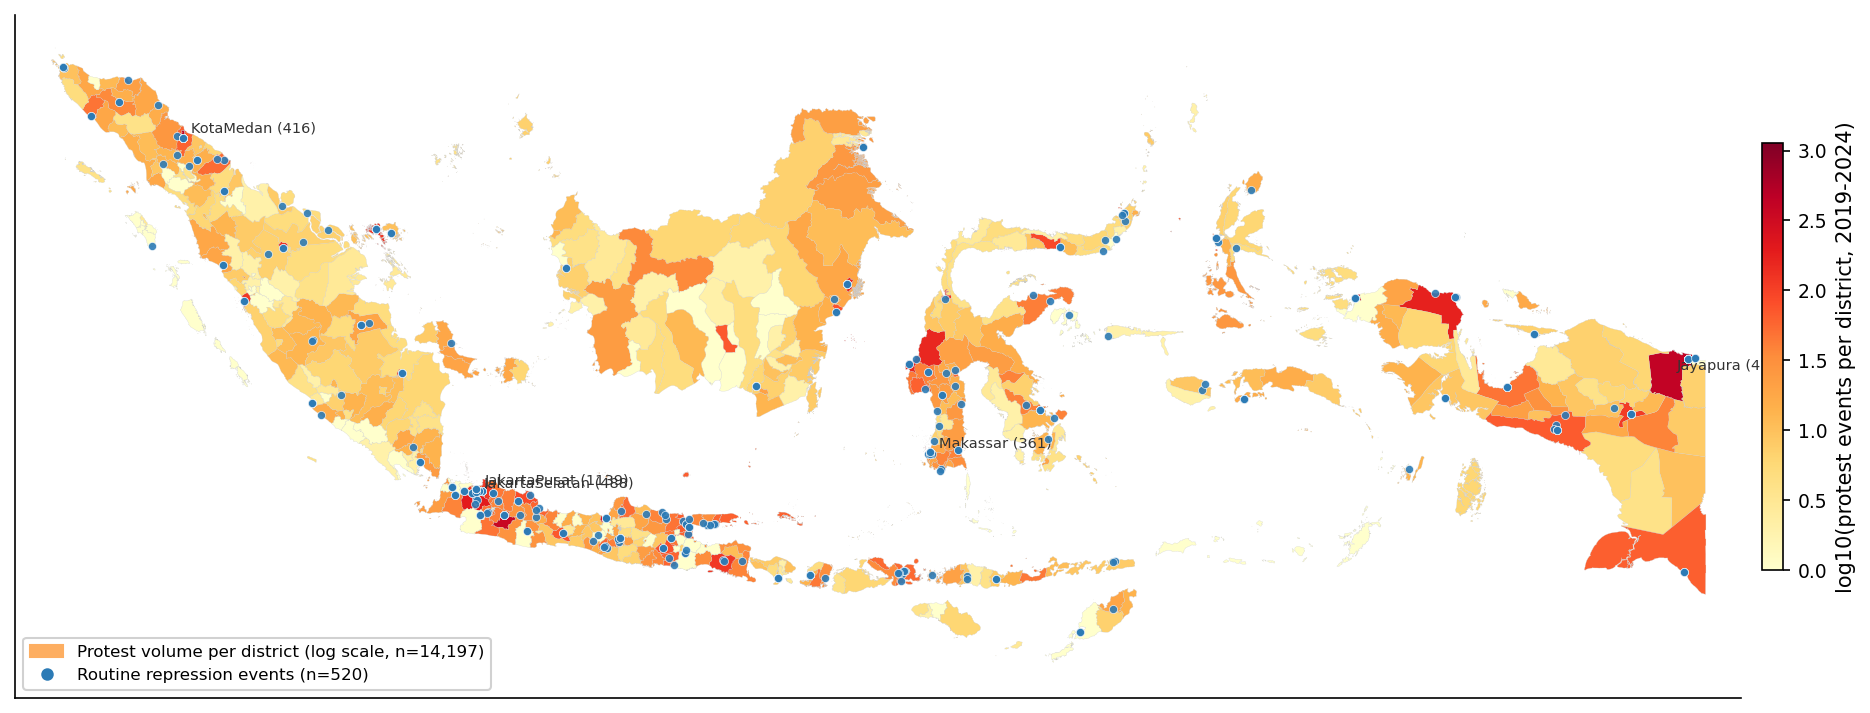

In [158]:
# Repression events (geo_precision=1 only)
rep_geo = acled_cl[
    (acled_cl.category=="routine") &
    (acled_cl.geo_precision==1) &
    (acled_cl.year != 2025)]

# Top 5 protest districts for annotation
top5 = (protest_total.nlargest(5,"n_protest")
        .merge(gadm[["GID_2","NAME_2"]], on="GID_2"))

fig, ax = plt.subplots(figsize=(14, 6))

# Layer 1: protest choropleth
gdf_p.plot(ax=ax, column="log_protest", cmap="YlOrRd",
           missing_kwds={"color":"#f0f0f0"},
           edgecolor="#cccccc", linewidth=0.12, legend=True,
           legend_kwds={"label":"log10(protest events per district, 2019-2024)",
                        "shrink":0.5,"pad":0.01})

# Layer 2: routine repression dots
ax.scatter(rep_geo.longitude, rep_geo.latitude,
           s=15, alpha=0.9, color="#2c7bb6",
           edgecolors="white", linewidth=0.3,
           zorder=5)

# Annotate top 5 protest districts
for _, row in top5.iterrows():
    geom = gadm[gadm.GID_2==row.GID_2].geometry.centroid.values[0]
    ax.annotate(f"{row.NAME_2} ({row.n_protest})",
                (geom.x, geom.y), fontsize=7,
                xytext=(4,2), textcoords="offset points", color="#333")

# Custom legend 
n_protest = int(protest_total.n_protest.sum())
n_routine  = len(rep_geo)
protest_patch = mpatches.Patch(
    color="#fdae61",
    label=f"Protest volume per district (log scale, n={n_protest:,})")
routine_dot = mlines.Line2D(
    [], [], color="#2c7bb6", marker="o",
    markersize=5, linestyle="None",
    label=f"Routine repression events (n={n_routine:,})")
ax.legend(handles=[protest_patch, routine_dot],
          loc="lower left", fontsize=8, framealpha=0.9)

ax.set_xlim(94,142); ax.set_ylim(-12,7)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(FIGS/"fig1_spatial_structure.png", dpi=200, bbox_inches="tight")
plt.show()

#### Figure 2. Panel sparsity diagnostic

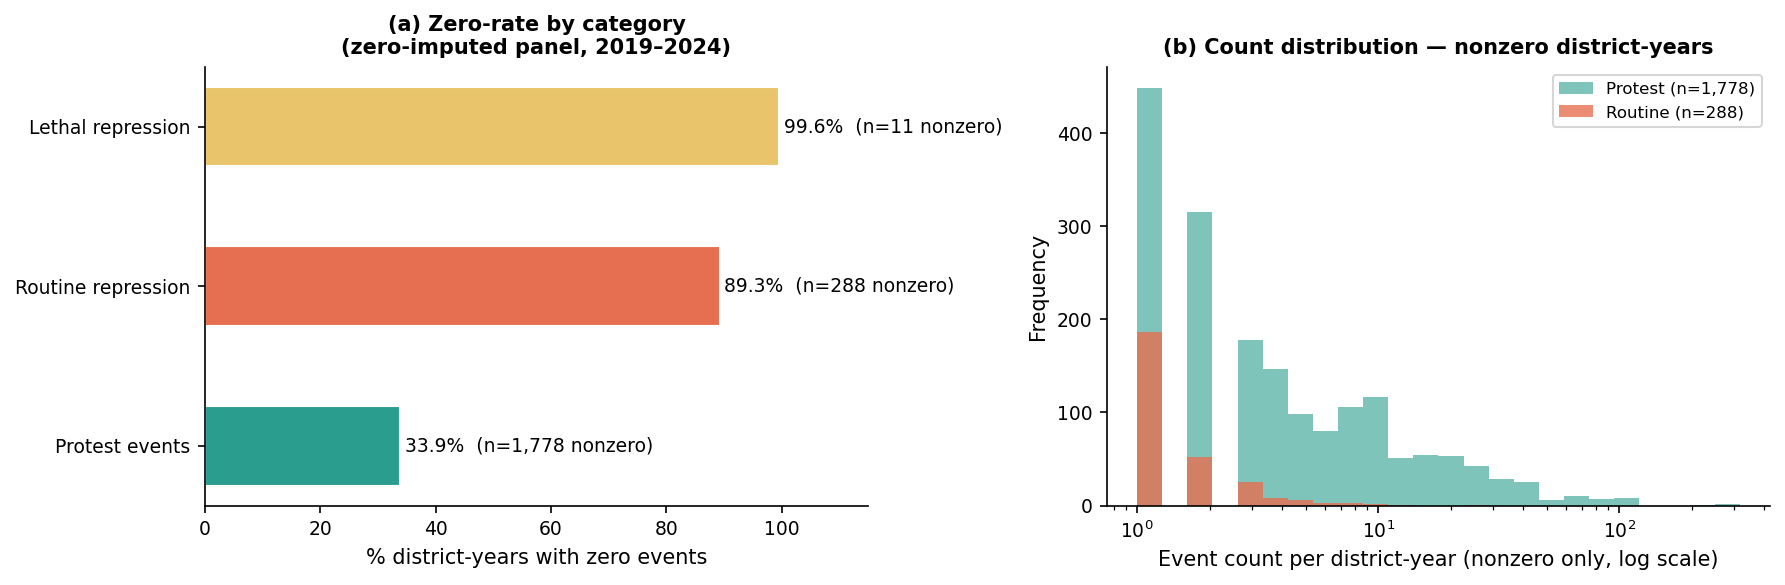

In [143]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cats   = ["protest","routine","lethal"]
labels = ["Protest events","Routine repression","Lethal repression"]
colors = ["#2A9D8F","#E76F51","#E9C46A"]
pct    = [(panel[c]==0).mean()*100 for c in cats]
nonzero_n = [(panel[c]>0).sum() for c in cats]

axes[0].barh(labels, pct, color=colors, edgecolor="white", height=0.5)
axes[0].set_xlabel("% district-years with zero events")
axes[0].set_xlim(0, 115)
axes[0].set_title("(a) Zero-rate by category\n(zero-imputed panel, 2019–2024)",
                  fontweight="bold")

for i, (v, n) in enumerate(zip(pct, nonzero_n)):
    axes[0].text(v+0.8, i, f"{v:.1f}%  (n={n:,} nonzero)", va="center", fontsize=9)

bins = np.logspace(0, 2.5, 25)
axes[1].hist(panel[panel.protest>0].protest, bins=bins, alpha=0.6,
             color="#2A9D8F", label=f"Protest (n={(panel.protest>0).sum():,})")
axes[1].hist(panel[panel.routine>0].routine, bins=bins, alpha=0.8,
             color="#E76F51", label=f"Routine (n={(panel.routine>0).sum():,})")
axes[1].set_xscale("log")
axes[1].set_xlabel("Event count per district-year (nonzero only, log scale)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("(b) Count distribution — nonzero district-years", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGS/"fig2_sparsity_diagnostic.png", dpi=200, bbox_inches="tight")
plt.show()


### Figure 3. Temporal decomposition

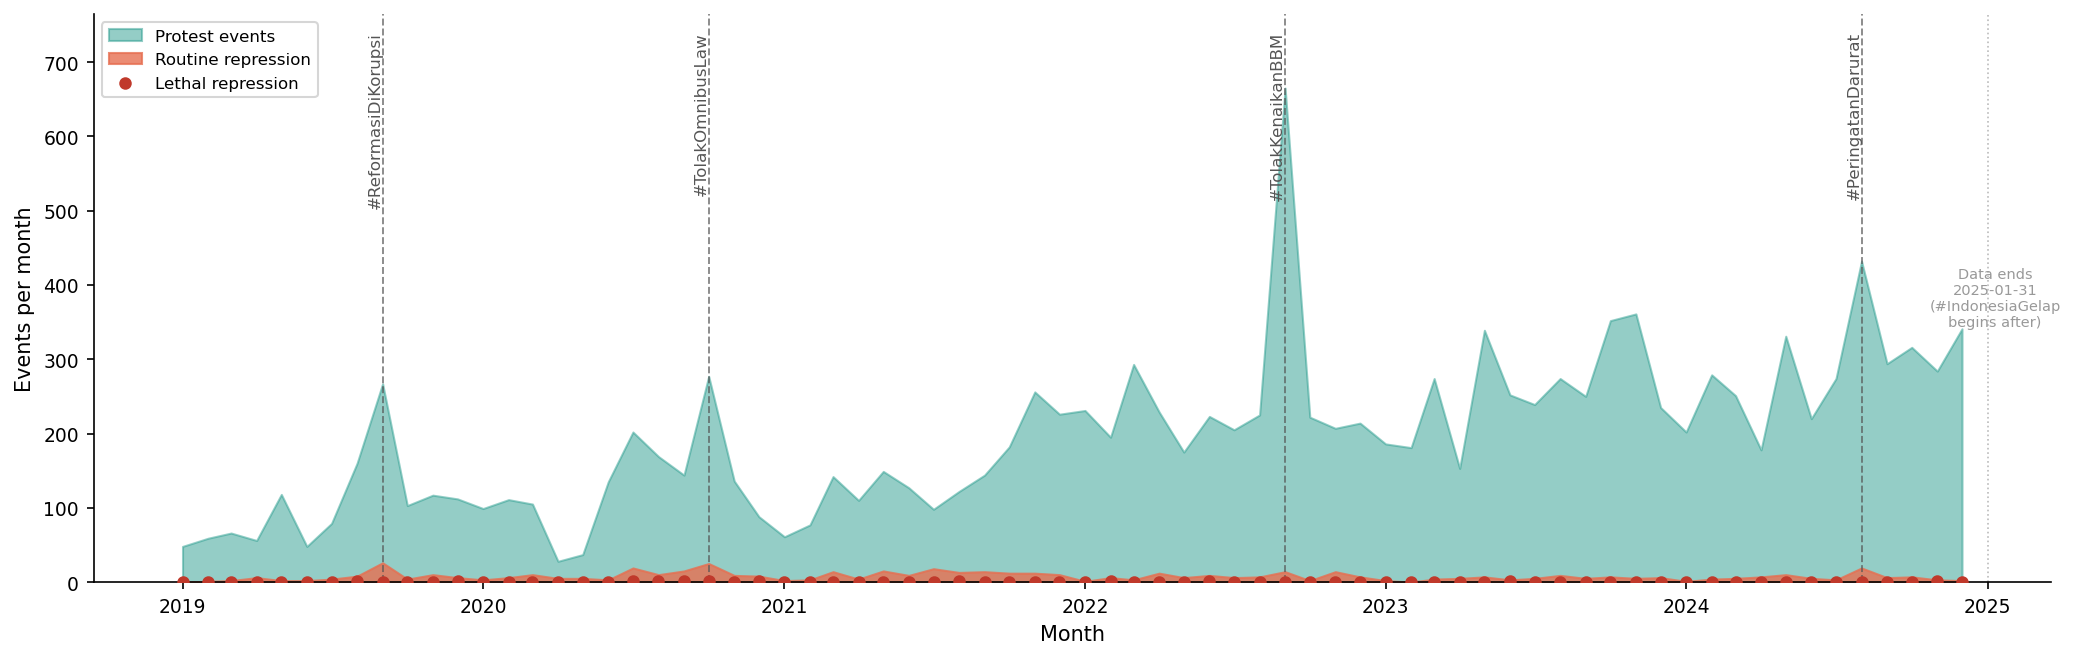

In [144]:
acled_plot = acled_cl[acled_cl.category.isin(["protest","routine","lethal"]) &
                      (acled_cl.year != 2025)]
monthly = (acled_plot
           .assign(month=acled_plot.event_date.dt.to_period("M"))
           .groupby(["month","category"]).size()
           .unstack(fill_value=0).reset_index())
monthly["month_dt"] = monthly.month.dt.to_timestamp()
for col in ["protest","routine","lethal"]:
    if col not in monthly.columns: monthly[col] = 0

WAVES = {
    "#ReformasiDiKorupsi": "2019-09-01",
    "#TolakOmnibusLaw":    "2020-10-01",
    "#TolakKenaikanBBM":   "2022-09-01",
    "#PeringatanDarurat":  "2024-08-01",
}

fig, ax = plt.subplots(figsize=(14, 4.5))
ymax = monthly.protest.max() * 1.15
ax.fill_between(monthly.month_dt, monthly.protest,
                alpha=0.5, color="#2A9D8F", label="Protest events")
ax.fill_between(monthly.month_dt, monthly.routine,
                alpha=0.8, color="#E76F51", label="Routine repression")
ax.scatter(monthly.month_dt, monthly.lethal,
           color="#c0392b", s=25, zorder=5, label="Lethal repression")
ax.set_ylim(0, ymax)

for name, date in WAVES.items():
    ax.axvline(pd.Timestamp(date), color="#555", linestyle="--", linewidth=0.9, alpha=0.7)
    ax.text(pd.Timestamp(date), ymax*0.97, name,
            rotation=90, fontsize=8, va="top", ha="right", color="#555")

ax.text(pd.Timestamp("2025-01-10"), ymax*0.5,
        "Data ends\n2025-01-31\n(#IndonesiaGelap\nbegins after)",
        fontsize=7, color="#999", ha="center", va="center")
ax.axvline(pd.Timestamp("2025-01-01"), color="#bbb", linestyle=":", linewidth=0.8)
ax.set_xlabel("Month"); ax.set_ylabel("Events per month")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(FIGS/"fig3_temporal_waves.png", dpi=200, bbox_inches="tight")
plt.show()


### Figure 4. NDBI, routine repression, and spatial correlation

In [112]:
print(cs.groupby(["region","NAME_1"]).size().reset_index(name="n")
        .sort_values(["region","NAME_1"]).to_string(index=False))

    region            NAME_1  n
 Bali & NT              Bali  9
 Bali & NT NusaTenggaraBarat  8
 Bali & NT NusaTenggaraTimur 15
      Java            Banten  5
      Java       JakartaRaya  5
      Java         JawaBarat 19
      Java        JawaTengah 31
      Java         JawaTimur 31
      Java        Yogyakarta  5
Kalimantan   KalimantanBarat 11
Kalimantan KalimantanSelatan 13
Kalimantan  KalimantanTengah 14
Kalimantan   KalimantanTimur  9
    Maluku            Maluku  7
    Maluku       MalukuUtara  7
     Papua             Papua 17
     Papua        PapuaBarat  8
  Sulawesi         Gorontalo  4
  Sulawesi     SulawesiBarat  4
  Sulawesi   SulawesiSelatan 22
  Sulawesi    SulawesiTengah 10
  Sulawesi  SulawesiTenggara  9
  Sulawesi     SulawesiUtara  9
   Sumatra              Aceh 21
   Sumatra    BangkaBelitung  7
   Sumatra          Bengkulu  9
   Sumatra             Jambi 10
   Sumatra     KepulauanRiau  5
   Sumatra           Lampung 10
   Sumatra              Riau 11
   Sumat

In [161]:
# NDBI x routine repression
rho_pool, p_pool = spearmanr(cs.NDBI_mean, cs.log_n_routine)
region_stats = {}
for region, grp in cs.groupby("region"):
    if len(grp) < 10: continue
    r, p = spearmanr(grp.NDBI_mean, grp.log_n_routine)
    region_stats[region] = (r, p, len(grp))

print(f"Pooled rho = {rho_pool:.3f}  (p = {p_pool:.2e}, n = {len(cs)})")
for r, (rho, p, n) in region_stats.items():
    sig = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.10 else ""
    print(f"  {r:<20} rho={rho:+.3f}  p={p:.4f} {sig}  n={n}")

Pooled rho = 0.285  (p = 8.23e-09, n = 395)
  Bali & NT            rho=+0.320  p=0.0746 *  n=32
  Java                 rho=+0.249  p=0.0145 **  n=96
  Kalimantan           rho=+0.274  p=0.0625 *  n=47
  Maluku               rho=+0.645  p=0.0127 **  n=14
  Papua                rho=-0.227  p=0.2759   n=25
  Sulawesi             rho=+0.373  p=0.0039 ***  n=58
  Sumatra              rho=+0.178  p=0.0487 **  n=123


In [162]:
# NDBI x protest
rho_p, p_p = spearmanr(cs.NDBI_mean, cs.log_n_protest)
print(f"\nPooled Spearman rho (NDBI x log_protest): rho = {rho_p:.3f}  (p = {p_p:.2e}, n = {len(cs)})")

print("\nWithin-region (NDBI x protest):")
print(f"{'Region':<20} {'n':>4} {'rho':>7} {'p':>8}")

for region, grp in cs.groupby("region"):
    if len(grp) < 10: continue
    r, p = spearmanr(grp.NDBI_mean, grp.log_n_protest)
    sig = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.10 else ""
    print(f"{region:<20} {len(grp):>4} {r:>7.3f} {p:>8.4f} {sig}")


Pooled Spearman rho (NDBI x log_protest): rho = 0.422  (p = 1.78e-18, n = 395)

Within-region (NDBI x protest):
Region                  n     rho        p
Bali & NT              32   0.221   0.2248 
Java                   96   0.329   0.0011 ***
Kalimantan             47   0.219   0.1393 
Maluku                 14   0.541   0.0455 **
Papua                  25  -0.106   0.6142 
Sulawesi               58   0.324   0.0131 **
Sumatra               123   0.181   0.0445 **


In [163]:
# Pooled + within-region NDBI x routine repression x protest

rows = []
# Pooled
r_rep, p_rep = spearmanr(cs.NDBI_mean, cs.log_n_routine)
r_pro, p_pro = spearmanr(cs.NDBI_mean, cs.log_n_protest)
rows.append({
    "Region": "Pooled",
    "n": len(cs),
    "rho (NDBI x routine)": r_rep,
    "p (routine)": p_rep,
    "rho (NDBI x protest)": r_pro,
    "p (protest)": p_pro,
})

# Within-region
for region, grp in cs.groupby("region"):
    if len(grp) < 10: continue
    r_rep, p_rep = spearmanr(grp.NDBI_mean, grp.log_n_routine)
    r_pro, p_pro = spearmanr(grp.NDBI_mean, grp.log_n_protest)
    rows.append({
        "Region": region,
        "n": len(grp),
        "rho (NDBI x routine)": r_rep,
        "p (routine)": p_rep,
        "rho (NDBI x protest)": r_pro,
        "p (protest)": p_pro,
    })

df_spear = pd.DataFrame(rows)

def fmt(rho, p):
    stars = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.10 else ""
    return f"{rho:+.3f}{stars}"

print("Table. Spearman rank correlations: NDBI x routine repression and NDBI x protest")
print(f"{'Region':<20} {'n':>4}  {'rho (NDBI x routine)':>18}  {'rho (NDBI x protest)':>18}")

for _, row in df_spear.iterrows():
    sep = "─"*64 if row.Region == "Bali & NT" else ""
    if sep: print(sep)
    print(f"{row.Region:<20} {int(row.n):>4}  "
          f"{fmt(row['rho (NDBI x routine)'], row['p (routine)']):>18}  "
          f"{fmt(row['rho (NDBI x protest)'], row['p (protest)']):>18}")

print("* p<0.10, ** p<0.05, *** p<0.01")
print("Note: Maluku n=14, interpret with caution.")

Table. Spearman rank correlations: NDBI x routine repression and NDBI x protest
Region                  n  rho (NDBI x routine)  rho (NDBI x protest)
Pooled                395           +0.285***           +0.422***
────────────────────────────────────────────────────────────────
Bali & NT              32             +0.320*              +0.221
Java                   96            +0.249**           +0.329***
Kalimantan             47             +0.274*              +0.219
Maluku                 14            +0.645**            +0.541**
Papua                  25              -0.227              -0.106
Sulawesi               58           +0.373***            +0.324**
Sumatra               123            +0.178**            +0.181**
* p<0.10, ** p<0.05, *** p<0.01
Note: Maluku n=14, interpret with caution.


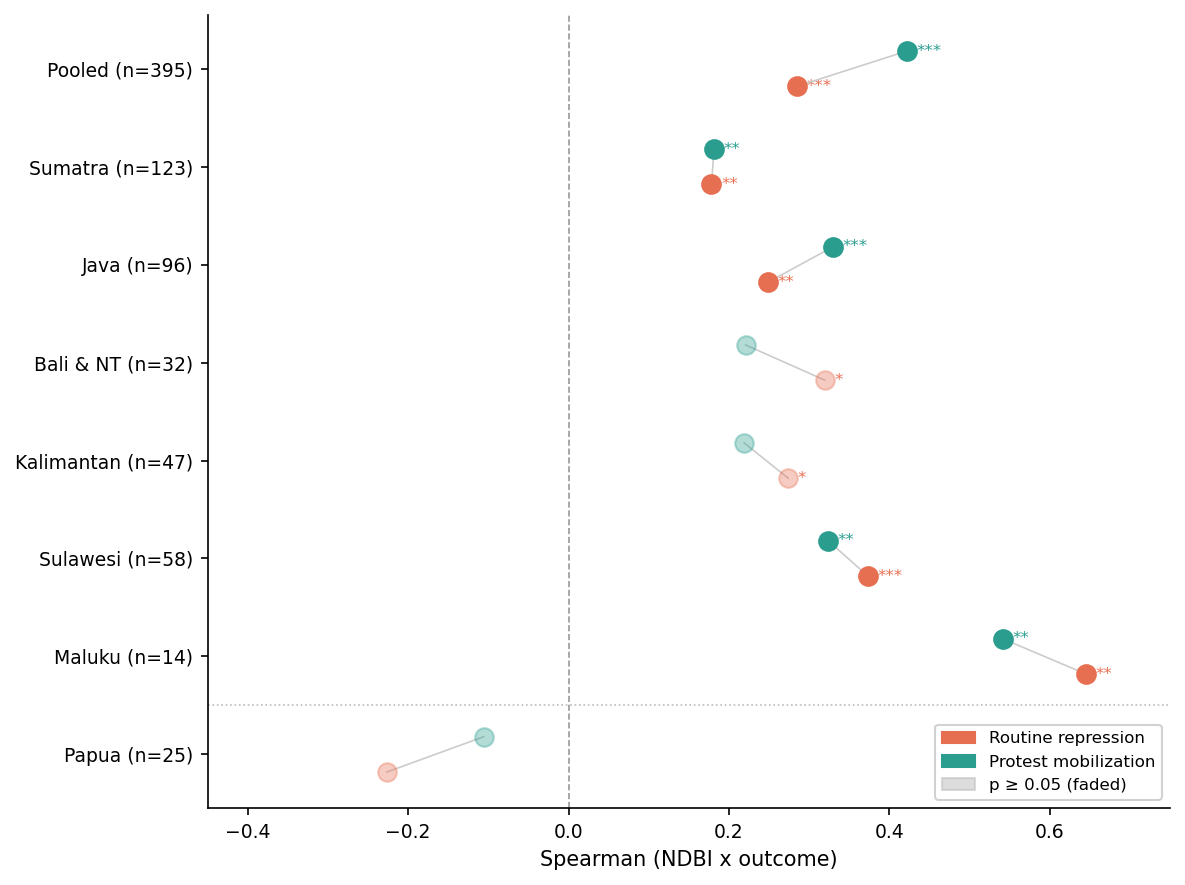

In [165]:
rows = []
region_order = ["Pooled","Sumatra","Java","Bali & NT",
                "Kalimantan","Sulawesi","Maluku","Papua"]

for region in region_order:
    if region == "Pooled":
        grp = cs
    else:
        grp = cs[cs.region == region]
    if len(grp) < 10: continue
    r_rep, p_rep = spearmanr(grp.NDBI_mean, grp.log_n_routine)
    r_pro, p_pro = spearmanr(grp.NDBI_mean, grp.log_n_protest)
    rows.append({
        "region": region,
        "n": len(grp),
        "rho_routine": r_rep, "p_routine": p_rep,
        "rho_protest": r_pro, "p_protest": p_pro,
    })

df_s = pd.DataFrame(rows)

def stars(p):
    return "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.10 else ""

fig, ax = plt.subplots(figsize=(8, 6))

y_pos = np.arange(len(df_s))
offset = 0.18

for i, row in df_s.iterrows():
    y = y_pos[i]
    # Routine
    ax.scatter(row.rho_routine, y + offset,
               color="#E76F51", s=80, zorder=5,
               marker="o" if row.p_routine < 0.05 else "o",
               alpha=1.0 if row.p_routine < 0.05 else 0.35)
    # Protest
    ax.scatter(row.rho_protest, y - offset,
               color="#2A9D8F", s=80, zorder=5,
               alpha=1.0 if row.p_protest < 0.05 else 0.35)
    # Stars
    if stars(row.p_routine):
        ax.text(row.rho_routine + 0.012, y + offset,
                stars(row.p_routine), fontsize=8,
                va="center", color="#E76F51")
    if stars(row.p_protest):
        ax.text(row.rho_protest + 0.012, y - offset,
                stars(row.p_protest), fontsize=8,
                va="center", color="#2A9D8F")
    # Connector line
    ax.plot([row.rho_routine, row.rho_protest],
            [y + offset, y - offset],
            color="#ccc", linewidth=0.8, zorder=3)

# Reference line at 0
ax.axvline(0, color="#333", linewidth=0.8, linestyle="--", alpha=0.5)

# Separator between Pooled and regions
ax.axhline(len(df_s) - 1.5, color="#bbb", linewidth=0.8, linestyle=":")

# Labels
region_labels = [
    f"{row.region} (n={row.n})" for _, row in df_s.iterrows()
]
ax.set_yticks(y_pos)
ax.set_yticklabels(region_labels, fontsize=9)
ax.set_xlabel("Spearman (NDBI x outcome)", fontsize=10)
ax.set_xlim(-0.45, 0.75)

# Legend
legend_handles = [
    mpatches.Patch(color="#E76F51", label="Routine repression"),
    mpatches.Patch(color="#2A9D8F", label="Protest mobilization"),
    mpatches.Patch(color="#aaaaaa", alpha=0.4, label="p ≥ 0.05 (faded)"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=8, framealpha=0.9)

ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGS/"fig_spearman_dotplot.png", dpi=200, bbox_inches="tight")
plt.show()

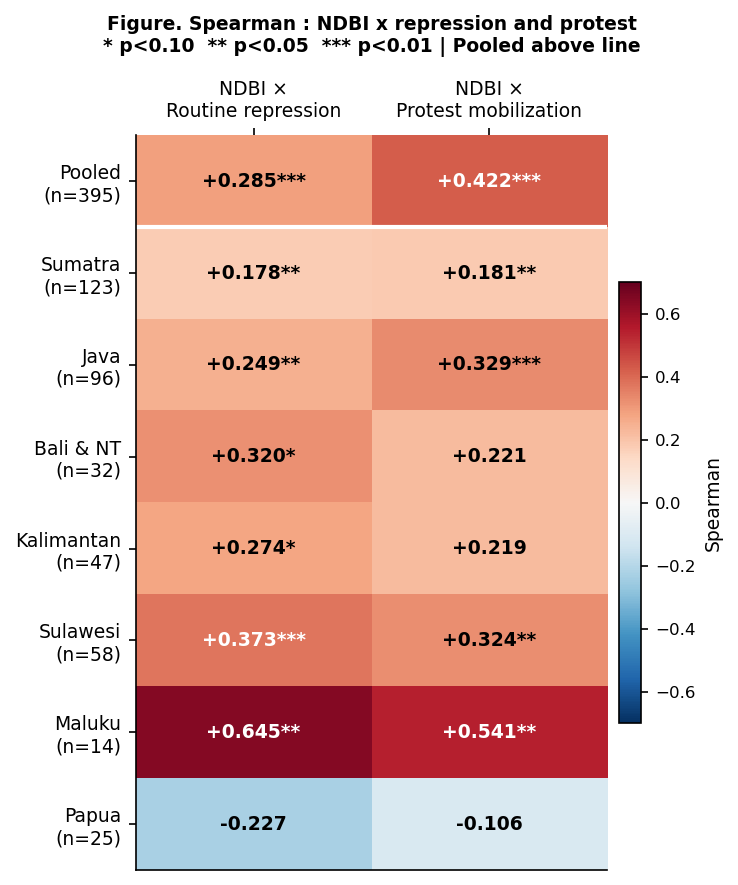

In [169]:
cols = ["rho (NDBI x routine)", "rho (NDBI x protest)"]
matrix = df_s[["rho_routine","rho_protest"]].values
p_matrix = df_s[["p_routine","p_protest"]].values
region_labels_short = [
    f"{row.region}\n(n={row.n})" for _, row in df_s.iterrows()
]

fig, ax = plt.subplots(figsize=(5, 6))

# Diverging colormap centered at 0
vabs = 0.7
im = ax.imshow(matrix, cmap="RdBu_r", vmin=-vabs, vmax=vabs, aspect="auto")

# Cell annotations
for i in range(len(df_s)):
    for j in range(2):
        rho = matrix[i, j]
        p   = p_matrix[i, j]
        sig = stars(p)
        txt = f"{rho:+.3f}{sig}"
        
        textcolor = "white" if abs(rho) > 0.35 else "black"
        ax.text(j, i, txt, ha="center", va="center",
                fontsize=9, color=textcolor, fontweight="bold")

# Separator between Pooled and regions
ax.axhline(0.5, color="white", linewidth=2)

ax.set_xticks([0, 1])
ax.set_xticklabels(["NDBI ×\nRoutine repression",
                    "NDBI ×\nProtest mobilization"], fontsize=9)
ax.set_yticks(range(len(df_s)))
ax.set_yticklabels(region_labels_short, fontsize=9)
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Spearman", fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax.set_title(
    "Figure. Spearman : NDBI x repression and protest\n"
    "* p<0.10  ** p<0.05  *** p<0.01 | Pooled above line",
    fontweight="bold", fontsize=9, pad=40)

plt.tight_layout()
plt.savefig(FIGS/"fig_spearman_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

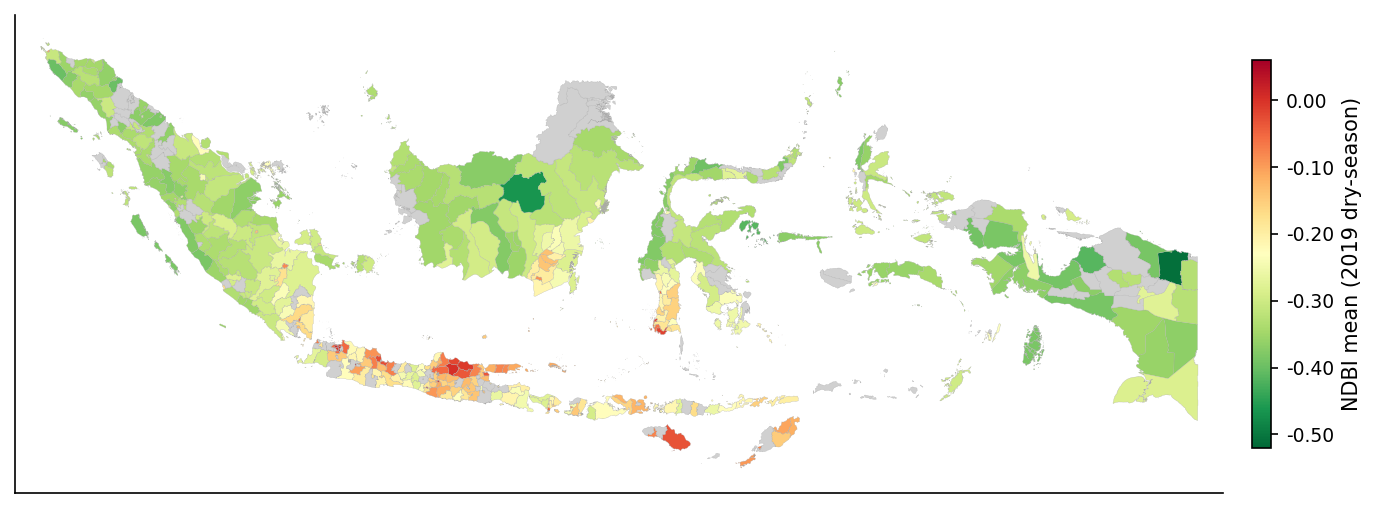

In [145]:

# Panel a: NDBI choropleth
gdf = (gadm[["GID_2","geometry"]]
       .merge(cs, on="GID_2", how="left")
       .reset_index(drop=True))

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
gdf.plot(ax=ax, column="NDBI_mean", cmap="RdYlGn_r",
         vmin=-0.52, vmax=0.06,
         missing_kwds={"color":"#d0d0d0"},
         edgecolor="#aaaaaa", linewidth=0.12, legend=True,
         legend_kwds={"label":"NDBI mean (2019 dry-season)",
                      "shrink":0.55,"pad":0.02,"format":"%.2f"})
ax.set_xlim(94,142); ax.set_ylim(-12,7); ax.set_aspect("equal")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(FIGS/"fig4a_ndbi_map.png", dpi=200, bbox_inches="tight")
plt.show()


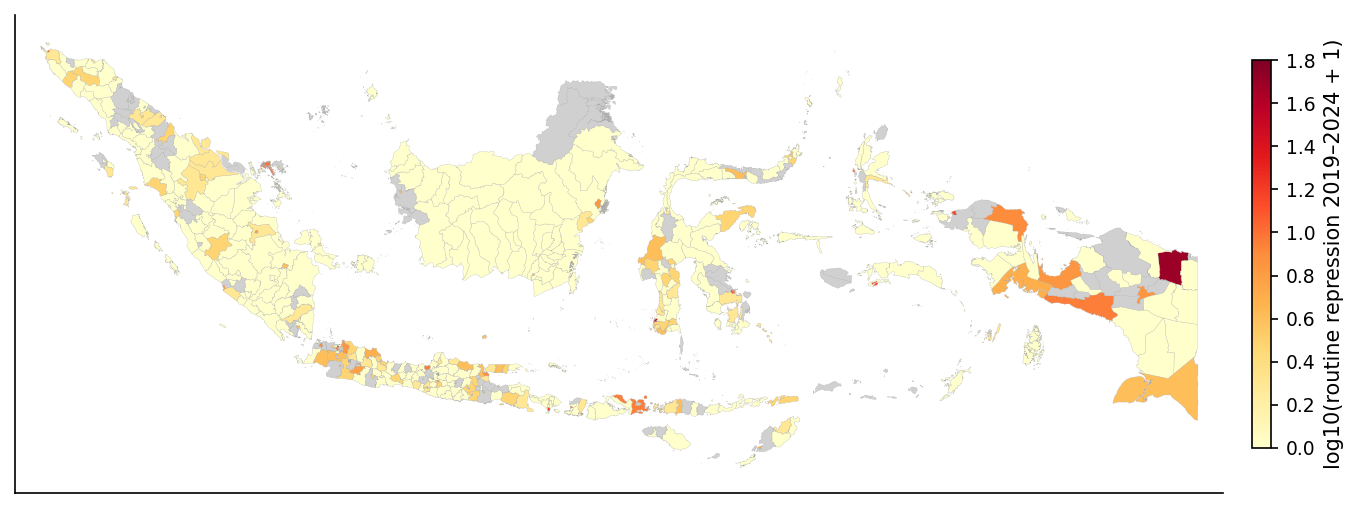

In [170]:
# Panel b: Routine repression choropleth
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
gdf.plot(ax=ax, column="log_n_routine", cmap="YlOrRd",
         vmin=0, vmax=1.8,
         missing_kwds={"color":"#d0d0d0"},
         edgecolor="#aaaaaa", linewidth=0.12, legend=True,
         legend_kwds={"label":"log10(routine repression 2019–2024 + 1)",
                      "shrink":0.55,"pad":0.02,"format":"%.1f"})
ax.set_xlim(94,142); ax.set_ylim(-12,7); ax.set_aspect("equal")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(FIGS/"fig4b_routine_map.png", dpi=200, bbox_inches="tight")
plt.show()

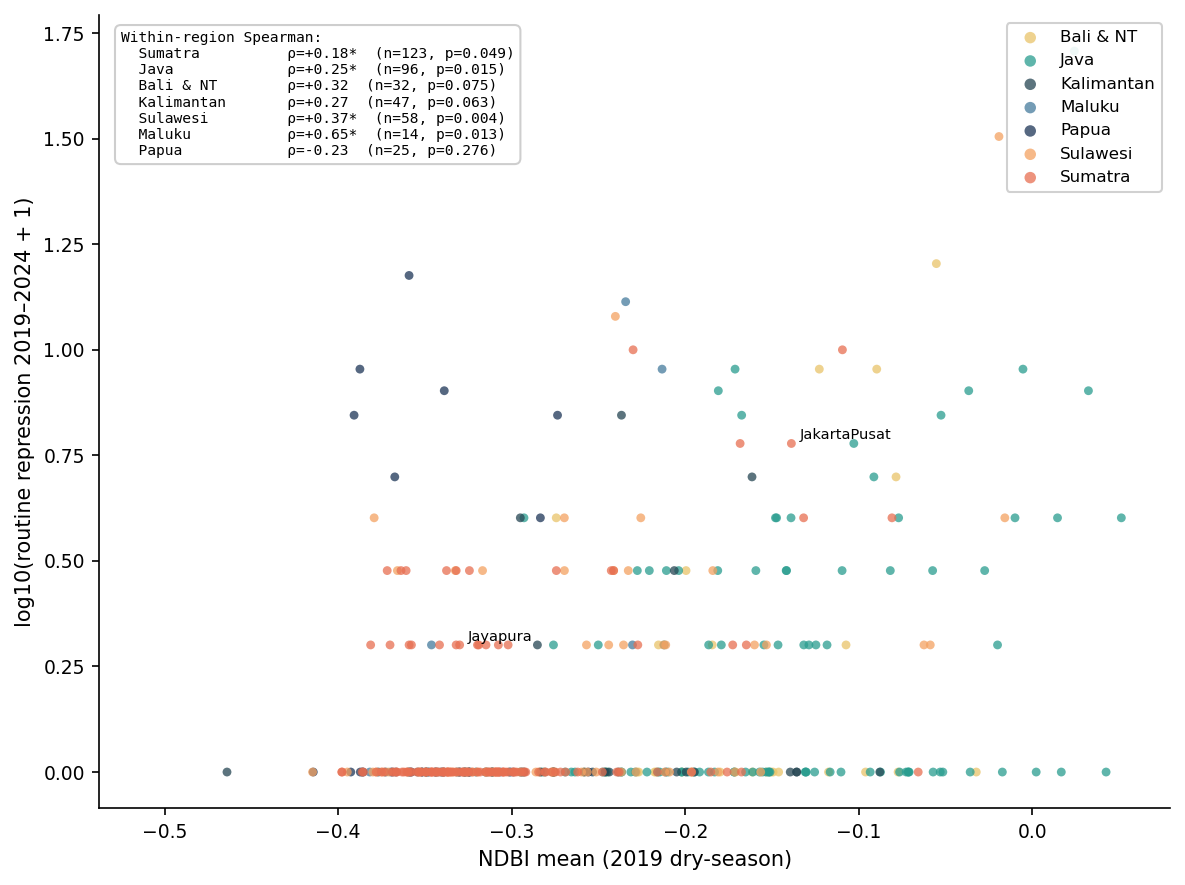

In [172]:
# Panel c: Scatter NDBI × routine
fig, ax = plt.subplots(figsize=(8, 6))
for region, grp in cs.groupby("region"):
    ax.scatter(grp.NDBI_mean, grp.log_n_routine,
               color=REGION_COLORS.get(region,"#999"),
               s=18, alpha=0.75, label=region, edgecolors="none")

for name, gid in [("Jayapura","IDN.24.1_1"),("JakartaPusat","IDN.8.3_1"),
                  ("Makassar","IDN.29.19_1")]:
    row = cs[cs.GID_2==gid]
    if len(row):
        ax.annotate(name, (row.NDBI_mean.values[0], row.log_n_routine.values[0]),
                    fontsize=7, xytext=(4,2), textcoords="offset points")

order = ["Sumatra", "Java", "Bali & NT", "Kalimantan", "Sulawesi", "Maluku", "Papua"]
lines = ["Within-region Spearman:"]
for r in order:
    if r not in region_stats: continue
    rho, p, n = region_stats[r]
    sig = "*" if p < 0.05 else ""
    lines.append(f"  {r:<16} ρ={rho:+.2f}{sig}  (n={n}, p={p:.3f})")
ax.text(0.02, 0.98, "\n".join(lines), transform=ax.transAxes,
        fontsize=7, va="top", fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#ccc", alpha=0.95))

ax.set_xlabel("NDBI mean (2019 dry-season)")
ax.set_ylabel("log10(routine repression 2019–2024 + 1)")
ax.legend(loc="upper right", markerscale=1.3, framealpha=0.9)
plt.tight_layout()
plt.savefig(FIGS/"fig4c_scatter.png", dpi=200, bbox_inches="tight")
plt.show()

### Figure 5. LISA cluster maps

In [173]:
gdf_lisa = (gadm[["GID_2","geometry"]]
                .merge(cs[["GID_2","log_n_protest","log_n_routine"]],
                       on="GID_2", how="left")
                .reset_index(drop=True))

w_q = libpysal.weights.Queen.from_dataframe(gdf_lisa, use_index=False)
w_k = libpysal.weights.KNN.from_dataframe(gdf_lisa, k=3, use_index=False)
w   = libpysal.weights.w_union(w_q, w_k) if w_q.islands else w_q
w.transform = "r"
print(f"Weights: n={w.n}, islands={w.islands}, mean_neighbors={w.mean_neighbors:.2f}")
    


Weights: n=502, islands=[], mean_neighbors=4.67


/opt/anaconda3/envs/agents/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 49 disconnected components.
 There are 29 islands with ids: 20, 21, 69, 236, 237, 239, 240, 242, 261, 262, 264, 265, 268, 274, 275, 276, 288, 294, 300, 301, 318, 354, 373, 391, 412, 418, 419, 426, 432.
  W.__init__(self, neighbors, ids=ids, **kw)
/opt/anaconda3/envs/agents/lib/python3.13/site-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
/opt/anaconda3/envs/agents/lib/python3.13/site-packages/libpysal/weights/set_operations.py:80: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
  return W(neighbors, **kwargs)


In [176]:
QUAD_LABEL = {1:"HH (hot spot)",2:"LH (spatial outlier)",
                  3:"LL (cold spot)",4:"HL (spatial outlier)"}
QUAD_COLOR = {"HH (hot spot)":"#d7191c","LH (spatial outlier)":"#abd9e9",
                  "LL (cold spot)":"#2c7bb6","HL (spatial outlier)":"#fdae61",
                  "Not significant":"#f0f0f0"}

variables = {"Protest (log)":"log_n_protest",
                 "Routine repression (log)":"log_n_routine"}
moran_res = {}

for label, col in variables.items():
    np.random.seed(42)
    y  = gdf_lisa[col].fillna(0).values
    mi = Moran(y, w, permutations=999)
    lm = Moran_Local(y, w, permutations=999, seed=42)
    moran_res[label] = mi
    short = col.replace("log_n_","")
    gdf_lisa[f"cluster_{short}"] = np.where(
        lm.p_sim < 0.05,
        pd.Series(lm.q).map(QUAD_LABEL).values,
        "Not significant")
    print(f"{label}: I={mi.I:.4f}, p={mi.p_sim:.4f}")
    print(gdf_lisa[f"cluster_{short}"].value_counts().to_string())
    print()


Protest (log): I=0.1234, p=0.0010
cluster_protest
Not significant         422
LL (cold spot)           35
HH (hot spot)            22
HL (spatial outlier)     13
LH (spatial outlier)     10

Routine repression (log): I=0.0101, p=0.3220
cluster_routine
Not significant         443
HL (spatial outlier)     33
LH (spatial outlier)     19
HH (hot spot)             7



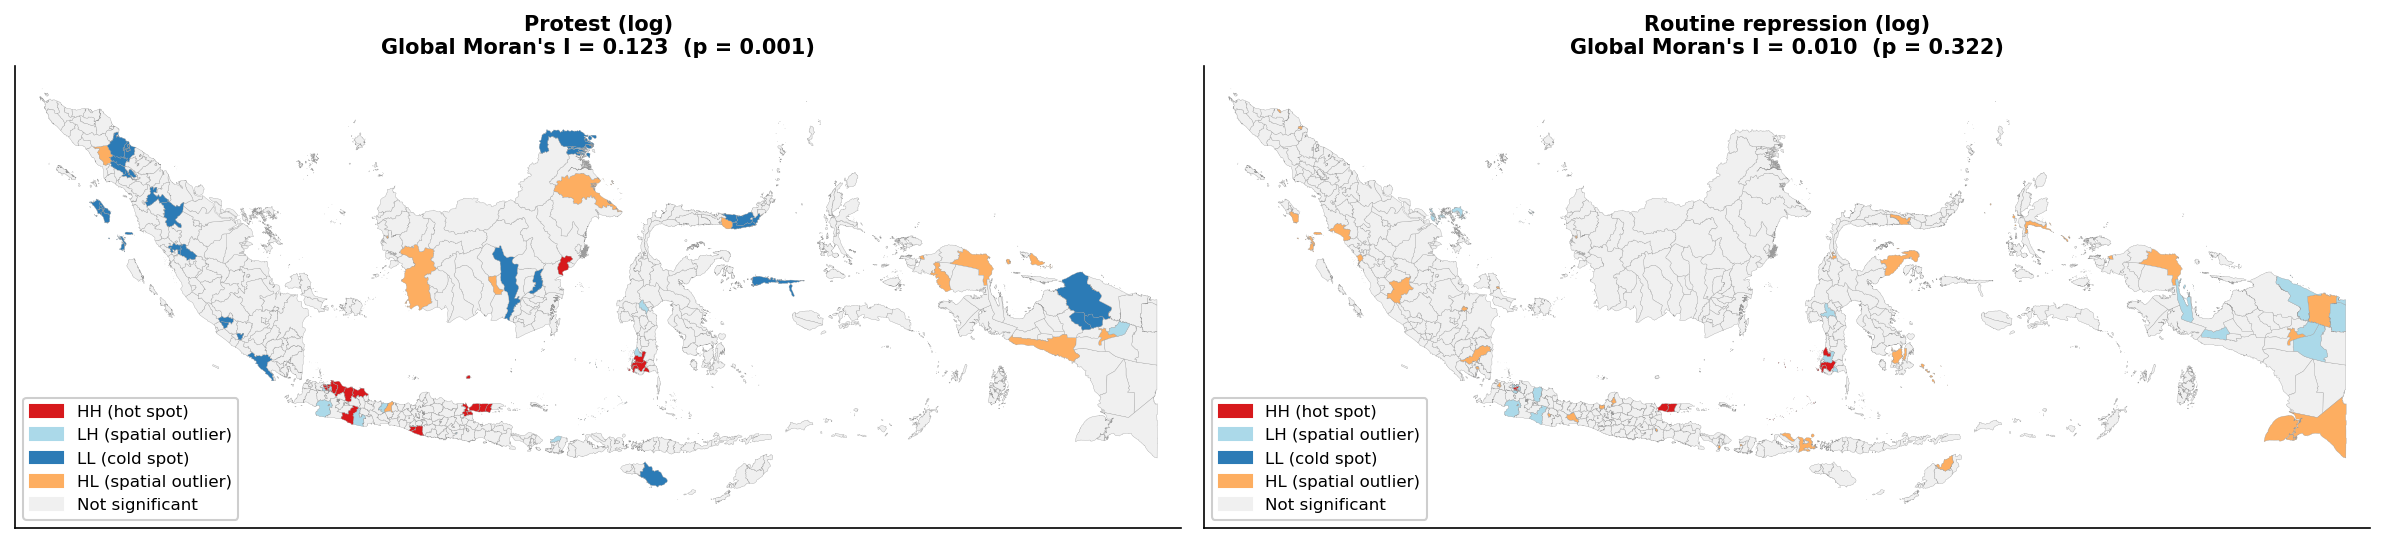

In [177]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for ax, (label, col) in zip(axes, variables.items()):
    short  = col.replace("log_n_","")
    colors = gdf_lisa[f"cluster_{short}"].map(QUAD_COLOR).fillna("#f0f0f0")
    gdf_lisa.plot(ax=ax, color=colors, edgecolor="#999", linewidth=0.15)
    ax.set_xlim(94,142); ax.set_ylim(-12,7)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    mi = moran_res[label]
    ax.set_title(f"{label}\nGlobal Moran's I = {mi.I:.3f}  (p = {mi.p_sim:.3f})",
                     fontweight="bold")
    patches = [mpatches.Patch(color=c, label=l) for l, c in QUAD_COLOR.items()]
    ax.legend(handles=patches, loc="lower left", fontsize=8, framealpha=0.95)


plt.tight_layout()
plt.savefig(FIGS/"fig5_lisa_clusters.png", dpi=200, bbox_inches="tight")
plt.show()
    


### Figure 6. OLS residual map --> where does the theory fit?

**Concept:** The OLS line predicts how much routine repression a district "should" have given its NDBI value.
- **Positive residual (red):** more repression than predicted --> factors beyond built environment are at work
- **Negative residual (blue):** less repression than predicted --> built environment alone overpredicts
- **Near zero (white):** the theory fits well in that district

In [179]:
# OLS: log_routine ~ NDBI
df_res = cs.dropna(subset=["NDBI_mean","log_n_routine"]).copy()
X = df_res.NDBI_mean.values.reshape(-1,1)
y = df_res.log_n_routine.values
reg = LinearRegression().fit(X, y)
df_res["predicted"] = reg.predict(X)
df_res["residual"]  = df_res.log_n_routine - df_res.predicted

print(f"OLS: log_routine = {reg.coef_[0]:.3f} x NDBI + {reg.intercept_:.3f}")
print(f"R2: {reg.score(X,y):.3f}")
print()
print("Top 5 positive residuals (more repression than NDBI predicts):")
print(df_res.nlargest(5,"residual")[["NAME_2","NAME_1","NDBI_mean",
                                     "log_n_routine","predicted","residual"]]
      .to_string(index=False))
print()
print("Top 5 negative residuals (less repression than predicted):")
print(df_res.nsmallest(5,"residual")[["NAME_2","NAME_1","NDBI_mean",
                                      "log_n_routine","predicted","residual"]]
      .to_string(index=False))


OLS: log_routine = 0.855 x NDBI + 0.385
R2: 0.086

Top 5 positive residuals (more repression than NDBI predicts):
      NAME_2          NAME_1  NDBI_mean  log_n_routine  predicted  residual
    Jayapura           Papua  -0.509555       1.698970  -0.051220  1.750190
JakartaPusat     JakartaRaya   0.024284       1.707570   0.405468  1.302102
    Makassar SulawesiSelatan  -0.019169       1.505150   0.368295  1.136855
  KotaSorong      PapuaBarat  -0.359142       1.176091   0.077456  1.098635
       Ambon          Maluku  -0.234322       1.113943   0.184236  0.929707

Top 5 negative residuals (less repression than predicted):
      NAME_2            NAME_1  NDBI_mean  log_n_routine  predicted  residual
      Cimahi         JawaBarat   0.042567            0.0   0.421110 -0.421110
JakartaBarat       JakartaRaya   0.016755            0.0   0.399027 -0.399027
       Blora        JawaTengah   0.002285            0.0   0.386649 -0.386649
JakartaUtara       JakartaRaya  -0.017216            0.0  

/var/folders/1b/zjf94sj90zd_m94w6wlhk5_r0000gn/T/ipykernel_19007/2303568495.py:24: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geom = gadm[gadm.GID_2==row.GID_2].geometry.centroid.values
/var/folders/1b/zjf94sj90zd_m94w6wlhk5_r0000gn/T/ipykernel_19007/2303568495.py:24: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geom = gadm[gadm.GID_2==row.GID_2].geometry.centroid.values
/var/folders/1b/zjf94sj90zd_m94w6wlhk5_r0000gn/T/ipykernel_19007/2303568495.py:24: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geom = gadm[gadm.GID_2==row.GID_2].geometry.centroid.values
/var/folde

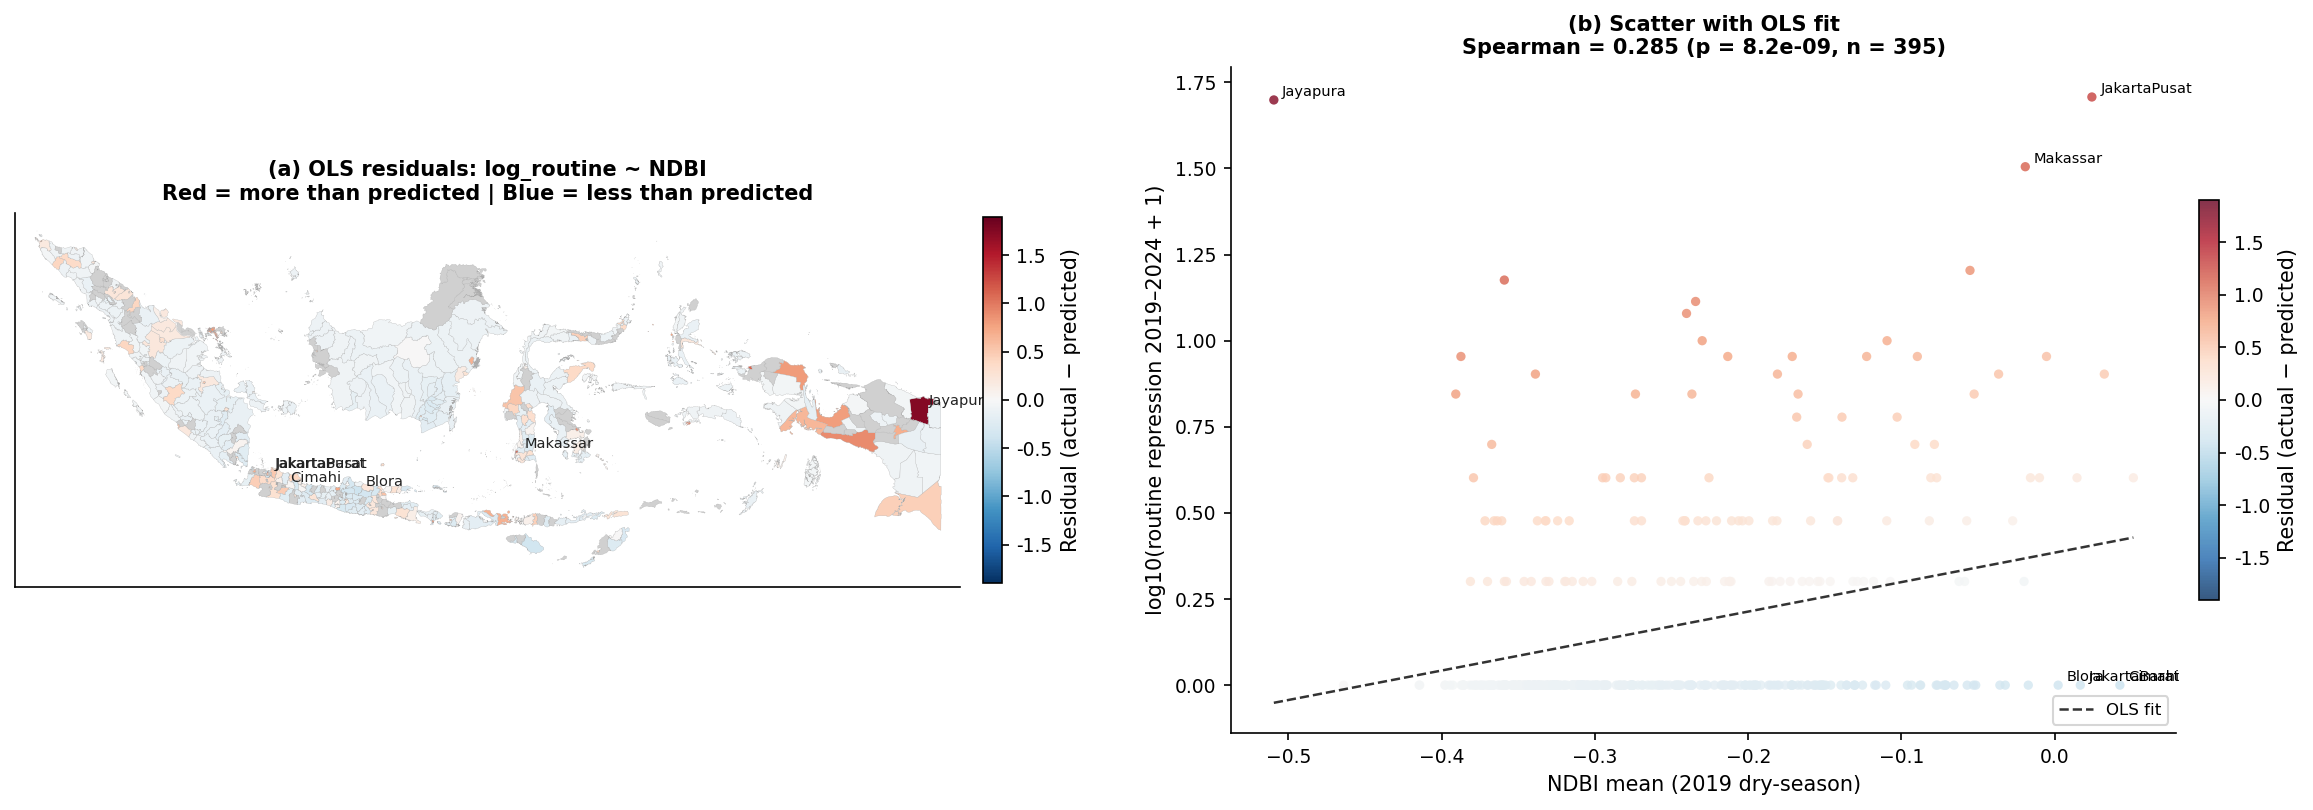

In [180]:

gdf_res = gadm[["GID_2","geometry"]].merge(
        df_res[["GID_2","residual","NAME_2","region"]],
        on="GID_2", how="left").reset_index(drop=True)

vabs = round(max(abs(df_res.residual.min()), abs(df_res.residual.max())), 1) + 0.1

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Panel a: choropleth
gdf_res.plot(ax=axes[0], column="residual", cmap="RdBu_r",
            vmin=-vabs, vmax=vabs,
            missing_kwds={"color":"#d0d0d0"},
            edgecolor="#aaaaaa", linewidth=0.12, legend=True,
            legend_kwds={"label":"Residual (actual − predicted)",
                        "shrink":0.55,"pad":0.02,"format":"%.1f"})
axes[0].set_xlim(94,142); axes[0].set_ylim(-12,7)
axes[0].set_aspect("equal"); axes[0].set_xticks([]); axes[0].set_yticks([])
axes[0].set_title("(a) OLS residuals: log_routine ~ NDBI\n"
                    "Red = more than predicted | Blue = less than predicted",
                    fontweight="bold")

for _, row in pd.concat([df_res.nlargest(3,"residual"),
                        df_res.nsmallest(3,"residual")]).iterrows():
    geom = gadm[gadm.GID_2==row.GID_2].geometry.centroid.values
    if len(geom):
        axes[0].annotate(row.NAME_2, (geom[0].x, geom[0].y),
                        fontsize=7, xytext=(4,2),
                        textcoords="offset points", color="#222")

    # Panel b: scatter
scatter = axes[1].scatter(df_res.NDBI_mean, df_res.log_n_routine,
                            c=df_res.residual, cmap="RdBu_r",
                            vmin=-vabs, vmax=vabs,
                            s=20, alpha=0.8, edgecolors="none")
x_line = np.linspace(df_res.NDBI_mean.min(), df_res.NDBI_mean.max(), 100)
axes[1].plot(x_line, reg.predict(x_line.reshape(-1,1)),
            color="#333", linewidth=1.2, linestyle="--", label="OLS fit")

for _, row in pd.concat([df_res.nlargest(3,"residual"),
                        df_res.nsmallest(3,"residual")]).iterrows():
        axes[1].annotate(row.NAME_2, (row.NDBI_mean, row.log_n_routine),
                    fontsize=7, xytext=(4,2), textcoords="offset points")

plt.colorbar(scatter, ax=axes[1], label="Residual (actual − predicted)",
            shrink=0.6, pad=0.02, format="%.1f")

rho, p = spearmanr(df_res.NDBI_mean, df_res.log_n_routine)
axes[1].set_xlabel("NDBI mean (2019 dry-season)")
axes[1].set_ylabel("log10(routine repression 2019–2024 + 1)")
axes[1].set_title(f"(b) Scatter with OLS fit\n"
                f"Spearman = {rho:.3f} (p = {p:.1e}, n = {len(df_res)})",
                fontweight="bold")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGS/"fig6_residual_map.png", dpi=200, bbox_inches="tight")
plt.show()


## 9. Spatial regression (Table 1)

In [181]:
df_reg = cs.dropna(subset=["NDBI_mean","NDVI_mean","n_protest","n_routine"]).copy()
region_dummies = pd.get_dummies(df_reg.region, prefix="reg", drop_first=True).astype(float)
df_reg = pd.concat([df_reg.reset_index(drop=True),
                    region_dummies.reset_index(drop=True)], axis=1)
region_cols = [c for c in df_reg.columns if c.startswith("reg_")]

gdf_reg = (gadm[["GID_2","geometry"]]
           .merge(df_reg[["GID_2"]], on="GID_2", how="inner")
           .reset_index(drop=True))
df_reg = (df_reg.set_index("GID_2")
          .loc[gdf_reg.GID_2.values].reset_index())

w_q = libpysal.weights.Queen.from_dataframe(gdf_reg, use_index=False)
w_k = libpysal.weights.KNN.from_dataframe(gdf_reg, k=3, use_index=False)
w_r = libpysal.weights.w_union(w_q, w_k) if w_q.islands else w_q
w_r.transform = "r"

y    = df_reg[["log_n_protest"]].values
Xb   = df_reg[["log_n_routine","NDBI_c","NDVI_c"]+region_cols].values
Xint = df_reg[["log_n_routine","NDBI_c","routine_x_NDBI","NDVI_c"]+region_cols].values
nb   = ["log_routine","NDBI","NDVI"]+region_cols
nint = ["log_routine","NDBI","routine×NDBI","NDVI"]+region_cols

m1 = OLS(y, Xb,   w=w_r, name_x=nb,   name_y="log_protest", spat_diag=True)
m2 = OLS(y, Xint, w=w_r, name_x=nint, name_y="log_protest", spat_diag=True)
m3 = ML_Lag(y,   Xint, w=w_r, name_x=nint, name_y="log_protest")
m4 = ML_Error(y, Xint, w=w_r, name_x=nint, name_y="log_protest")
print(f"Models fitted on n={m1.n} districts")


/opt/anaconda3/envs/agents/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 57 disconnected components.
 There are 37 islands with ids: 19, 20, 37, 38, 82, 103, 113, 122, 131, 132, 133, 134, 154, 198, 199, 201, 202, 214, 216, 217, 225, 226, 235, 239, 240, 243, 244, 246, 247, 251, 269, 271, 313, 330, 333, 334, 343.
  W.__init__(self, neighbors, ids=ids, **kw)
/opt/anaconda3/envs/agents/lib/python3.13/site-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 8 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
/opt/anaconda3/envs/agents/lib/python3.13/site-packages/libpysal/weights/set_operations.py:80: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
  return W(neighbors, **kwargs)
/opt/anaconda3/envs/agents/lib/python3.13/site-packages/spreg/ml_error.py:184: RuntimeWarning:

ML_Lag
ML_Error
Models fitted on n=395 districts


In [182]:
print(cs[["NDBI_mean","NDVI_mean","n_protest","n_routine"]].isna().sum())
print(f"cs total: {len(cs)}")
print(f"After dropna: {cs.dropna(subset=['NDBI_mean','NDVI_mean','n_protest','n_routine']).shape[0]}")

print(cs[["n_protest","n_routine"]].isna().sum())

print(f"panel_agg unique GID_2: {panel_agg.GID_2.nunique()}")
print(f"cs_prev unique GID_2: {cs_prev.GID_2.nunique()}")
print(f"Intersection: {len(set(panel_agg.GID_2) & set(cs_prev.GID_2))}")

NDBI_mean    0
NDVI_mean    0
n_protest    0
n_routine    0
dtype: int64
cs total: 395
After dropna: 395
n_protest    0
n_routine    0
dtype: int64
panel_agg unique GID_2: 448
cs_prev unique GID_2: 395
Intersection: 380


In [184]:

def fmt_row(models, varname, name_lists):
    cells_out = [f"{varname:<22}"]
    for model, names in zip(models, name_lists):
        betas = np.array(model.betas).flatten()
        ses   = (np.sqrt(np.diag(model.vm)) if hasattr(model,"vm")
                else np.array(model.std_err).flatten())
        all_names = ["(Intercept)"] + names
        if hasattr(model,"rho"): all_names += ["ρ"]
        if hasattr(model,"lam"): all_names += ["λ"]
        if varname not in all_names:
            cells_out.append(f"{'':>18}"); continue
        idx = all_names.index(varname)
        b, se = betas[idx], ses[idx]
        p = (2*(1-tdist.cdf(abs(b/se), df=model.n-model.k))
            if isinstance(model, OLS) else 2*(1-norm.cdf(abs(b/se))))
        stars = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.10 else ""
        cells_out.append(f"{b:+.3f}{stars:3s} ({se:.3f})")
    return "  ".join(cells_out)

all_vars = (["(Intercept)","log_routine","NDBI","routine x NDBI","NDVI"]
            + region_cols + ["rho","lambda"])


print("Table 1. Cross-sectional regression: log protest ~ routine repression × NDBI")
print(f"Zero-imputed panel; n={m1.n} districts; 2019–2024")

print(f"{'Variable':<22}  {'(1) OLS':>18}  {'(2) OLS+int':>18}  {'(3) SAR':>18}  {'(4) SEM':>18}")

for v in all_vars:
    print(fmt_row([m1,m2,m3,m4], v, [nb,nint,nint,nint]))

print(f"{'N':<22}  {m1.n:>18}  {m2.n:>18}  {m3.n:>18}  {m4.n:>18}")
print(f"{'R²/Pseudo-R²':<22}  {m1.r2:>18.3f}  {m2.r2:>18.3f}  {m3.pr2:>18.3f}  {m4.pr2:>18.3f}")
print(f"{'Log-likelihood':<22}  {'—':>18}  {'—':>18}  {m3.logll:>18.1f}  {m4.logll:>18.1f}")

print("*** p<0.01, ** p<0.05, * p<0.10. NDBI and NDVI mean-centered.")
print("Region FE: Bali & NT is reference. Weights: queen+k-NN(3), row-standardized.")


Table 1. Cross-sectional regression: log protest ~ routine repression × NDBI
Zero-imputed panel; n=395 districts; 2019–2024
Variable                           (1) OLS         (2) OLS+int             (3) SAR             (4) SEM
(Intercept)             +0.739*** (0.072)  +0.739*** (0.072)  +0.496*** (0.085)  +0.706*** (0.097)
log_routine             +1.170*** (0.069)  +1.186*** (0.071)  +1.185*** (0.068)  +1.125*** (0.065)
NDBI                    +1.227*** (0.353)  +1.316*** (0.367)  +1.254*** (0.355)  +1.789*** (0.399)
routine x NDBI                                                                                        
NDVI                    +0.446*   (0.237)  +0.411*   (0.240)  +0.426*   (0.230)  +0.462*   (0.245)
reg_Java                +0.382*** (0.079)  +0.380*** (0.079)  +0.277*** (0.079)  +0.381*** (0.108)
reg_Kalimantan          +0.071    (0.094)  +0.074    (0.094)  +0.121    (0.090)  +0.130    (0.127)
reg_Maluku              +0.095    (0.131)  +0.100    (0.131)  +0.082    (0.1

In [185]:

print("LM diagnostic tests (Model 2)")
print(f"LM-lag        = {m2.lm_lag[0]:.3f}  (p = {m2.lm_lag[1]:.3f})")
print(f"LM-error      = {m2.lm_error[0]:.3f}  (p = {m2.lm_error[1]:.3f})")
print(f"Robust LM-lag = {m2.rlm_lag[0]:.3f}  (p = {m2.rlm_lag[1]:.3f})")
print(f"Robust LM-err = {m2.rlm_error[0]:.3f}  (p = {m2.rlm_error[1]:.3f})")
print()
print("Decision rule (Anselin et al.):")
print("  Both significant - check robust versions")
print("  Robust LM with lower p - preferred specification")


LM diagnostic tests (Model 2)
LM-lag        = 22.538  (p = 0.000)
LM-error      = 19.496  (p = 0.000)
Robust LM-lag = 3.871  (p = 0.049)
Robust LM-err = 0.829  (p = 0.362)

Decision rule (Anselin et al.):
  Both significant - check robust versions
  Robust LM with lower p - preferred specification


## 10. Save outputs

In [132]:
panel.to_csv(PROC/"district_year_panel_v2.csv", index=False)
cs.to_csv(PROC/"district_cross_section_v2.csv", index=False)

print("Saved:")
print(f"  district_year_panel_v2.csv      — {len(panel):,} rows "
      f"({panel.GID_2.nunique()} districts × {panel.year.nunique()} years)")
print(f"  district_cross_section_v2.csv   — {len(cs)} districts")
print()
print("Panel totals by year:")
print(panel.groupby("year")[["protest","routine","lethal"]].sum().to_string())


Saved:
  district_year_panel_v2.csv      — 2,688 rows (448 districts × 6 years)
  district_cross_section_v2.csv   — 395 districts

Panel totals by year:
      protest  routine  lethal
year                          
2019     1216       71       2
2020     1522      118       6
2021     1680      122       1
2022     3051       87       2
2023     3065       57       1
2024     3342       72       1
